# Coffee Sales Analysis
Comprehensive business analysis of coffee sales transactions using reusable functions from the src package.

Last updated: 2026-03-29

## Environment and Imports
Set up paths and import only reusable project modules for ingestion, validation, cleaning, feature engineering, analysis, and plotting.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root / "src") not in sys.path:
    sys.path.append(str(project_root / "src"))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from analysis.product_analysis import (
    average_ticket_by_product,
    best_product_per_time_of_day,
    peak_product_per_hour,
    top_products_by_revenue,
    top_products_by_volume,
    underperforming_products,
)
from analysis.sales_analysis import sales_overview
from analysis.time_analysis import (
    hourly_sales,
    peak_weekday_hour,
    revenue_by_month,
    revenue_by_time_of_day,
    revenue_by_weekday,
    transactions_by_weekday,
)
from cleaning.clean_data import clean_sales_data
from config import settings
from features.time_features import derive_time_features
from ingestion.load_data import load_raw_sales_data
from validation.schema import assert_valid_dataset
from visualization.plots import (
    plot_hour_product_heatmap,
    plot_hourly_revenue,
    plot_hourly_transactions,
    plot_monthly_revenue,
    plot_time_of_day_revenue,
    plot_time_product_heatmap,
    plot_top_products,
    plot_weekday_hour_heatmap,
    plot_weekday_product_heatmap,
    plot_weekday_revenue,
)

## Data Preparation
Load raw data, validate schema constraints, clean records, and derive additional time features before analysis.

In [3]:
raw_df = load_raw_sales_data(settings.raw_data_path)
assert_valid_dataset(raw_df)

clean_df = clean_sales_data(raw_df)
analysis_df = derive_time_features(clean_df)

print(f"Raw rows: {raw_df.shape[0]}")
print(f"Rows after cleaning: {clean_df.shape[0]}")
print(f"Rows used for analysis: {analysis_df.shape[0]}")

Raw rows: 3547
Rows after cleaning: 3547
Rows used for analysis: 3547


In [4]:
display(analysis_df.head())

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,transaction_datetime,day_of_month,week_of_year,is_weekend,weekday_number,month_number
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50,2024-03-01 10:15:50,1,9,False,5,3
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22,2024-03-01 12:19:22,1,9,False,5,3
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18,2024-03-01 12:20:18,1,9,False,5,3
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33,2024-03-01 13:46:33,1,9,False,5,3
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14,2024-03-01 13:48:14,1,9,False,5,3


## Sales Overview
Answer baseline business questions: total transactions, total revenue, average ticket size, and product diversity.

In [5]:
overview = sales_overview(analysis_df)
overview_df = pd.DataFrame([overview])
display(overview_df)

,transactions,total_revenue,average_transaction_value,unique_products
0,3547,112245.58,31.645216,8


## Time-Based Analysis
Evaluate revenue and transaction behaviour by hour, weekday, month, and time-of-day bucket to identify operational peaks and trend structure. Answers Q2 (time-of-day revenue), Q3 (peak hour), Q4 (peak weekday), Q8 (monthly trend), and Q12 (hourly distribution).

In [6]:
hourly_df = hourly_sales(analysis_df)
weekday_df = revenue_by_weekday(analysis_df)
monthly_df = revenue_by_month(analysis_df)
tod_df = revenue_by_time_of_day(analysis_df)

display(hourly_df.head())
display(weekday_df)
display(monthly_df)
display(tod_df)

,hour_of_day,transactions,revenue
0,6,5,149.40
1,7,88,2846.02
2,8,235,7017.88
3,9,242,7264.28
4,10,328,10198.52


,Weekdaysort,Weekday,revenue
0,1,Mon,17363.10
1,2,Tue,18168.38
2,3,Wed,15750.46
3,4,Thu,16091.40
4,5,Fri,16802.66
5,6,Sat,14733.52
6,7,Sun,13336.06


,Monthsort,Month_name,revenue
0,1,Jan,6398.86
1,2,Feb,13215.48
2,3,Mar,15891.64
3,4,Apr,5719.56
4,5,May,8164.42
5,6,Jun,7617.76
6,7,Jul,6915.94
7,8,Aug,7613.84
8,9,Sep,9988.64
9,10,Oct,13891.16


,Time_of_Day,revenue
0,Night,38186.34
1,Afternoon,38130.04
2,Morning,35929.20


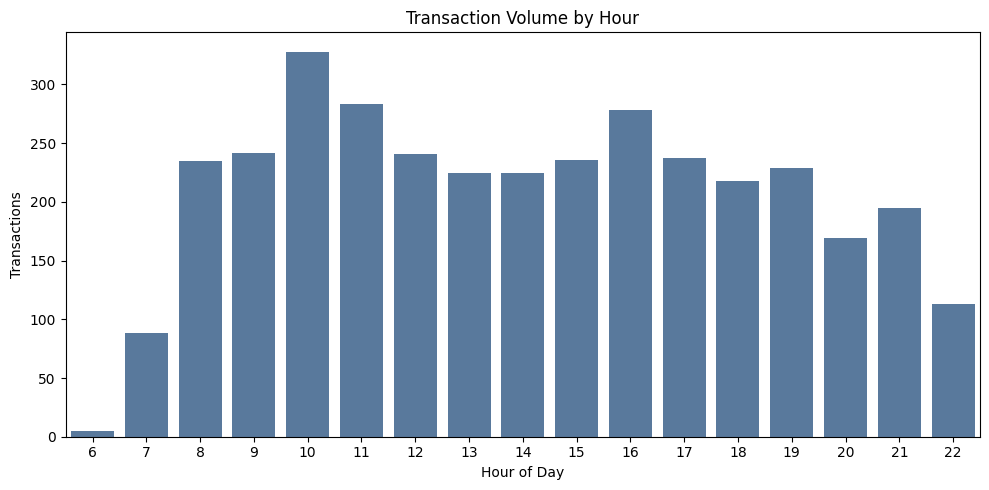

In [7]:
fig = plot_hourly_transactions(hourly_df)
plt.tight_layout()
plt.show()

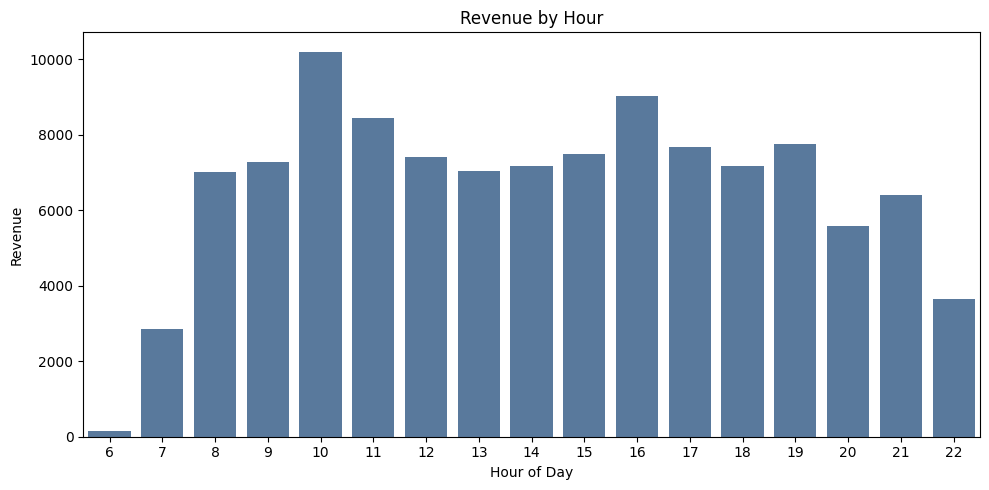

In [8]:
fig = plot_hourly_revenue(hourly_df)
plt.tight_layout()
plt.show()

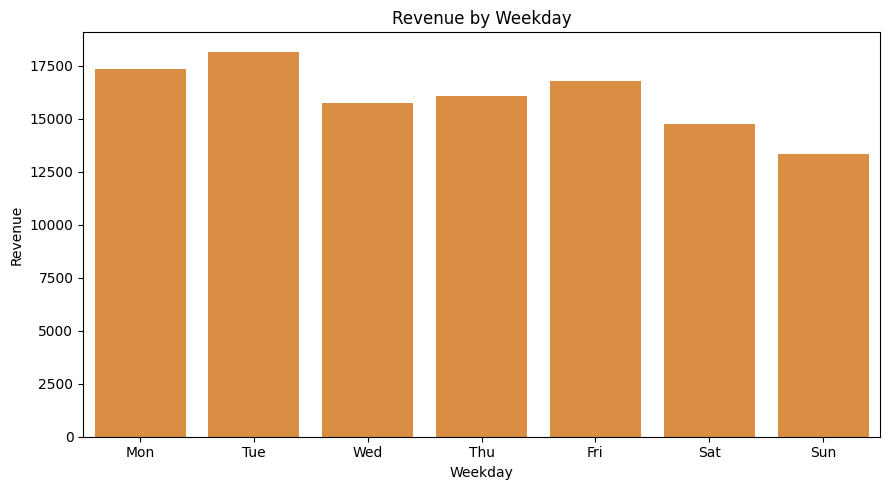

In [9]:
fig = plot_weekday_revenue(weekday_df)
plt.tight_layout()
plt.show()

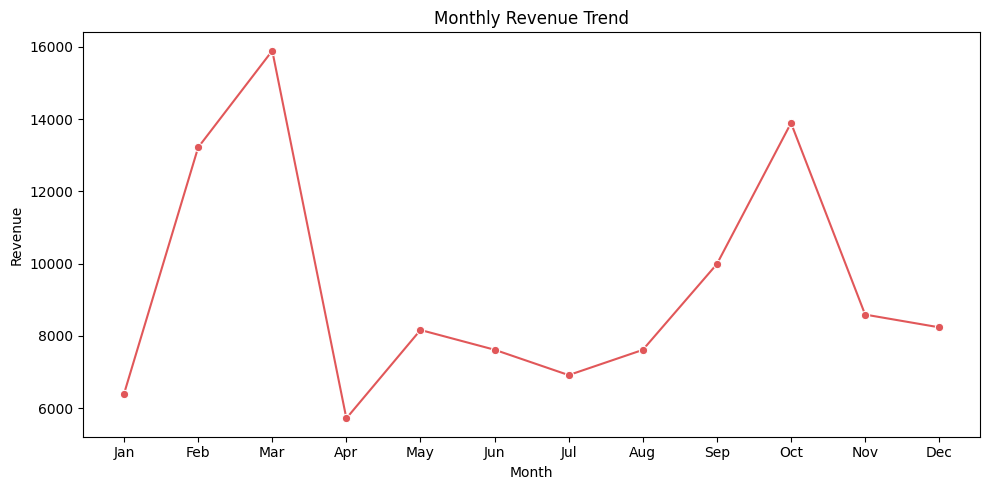

In [10]:
fig = plot_monthly_revenue(monthly_df)
plt.tight_layout()
plt.show()

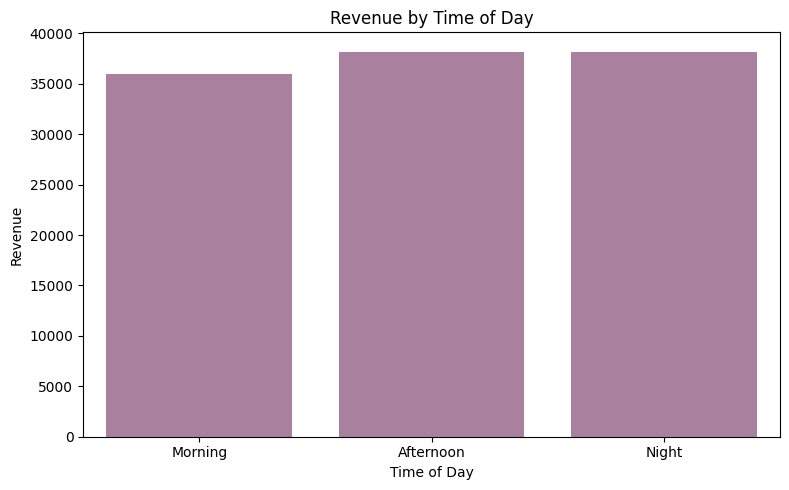

In [11]:
fig = plot_time_of_day_revenue(tod_df)
plt.tight_layout()
plt.show()

In [12]:
peak_hour = hourly_df.sort_values(["transactions", "revenue"], ascending=False).head(1)
peak_weekday = weekday_df.sort_values("revenue", ascending=False).head(1)
peak_tod = tod_df.head(1)

print("Q3 — Peak hour:")
display(peak_hour)
print("Q4 — Peak weekday by revenue:")
display(peak_weekday)
print("Q2 — Time of day with highest revenue:")
display(peak_tod)

Q3 — Peak hour:


,hour_of_day,transactions,revenue
4,10,328,10198.52


Q4 — Peak weekday by revenue:


,Weekdaysort,Weekday,revenue
1,2,Tue,18168.38


Q2 — Time of day with highest revenue:


,Time_of_Day,revenue
0,Night,38186.34


## Product Performance Analysis
Rank all 8 products by transaction volume, total revenue, and average ticket value. Answers Q1 (top by count), Q5 (top by revenue), and Q10 (average transaction value per product).

In [13]:
top_volume_df = top_products_by_volume(analysis_df, n=8)
top_revenue_df = top_products_by_revenue(analysis_df, n=8)
avg_ticket_df = average_ticket_by_product(analysis_df)

display(top_volume_df)
display(top_revenue_df)
display(avg_ticket_df)

,coffee_name,quantity
0,Americano with Milk,809
1,Latte,757
2,Americano,564
3,Cappuccino,486
4,Cortado,287
5,Hot Chocolate,276
6,Cocoa,239
7,Espresso,129


,coffee_name,revenue
0,Latte,26875.30
1,Americano with Milk,24751.12
2,Cappuccino,17439.14
3,Americano,14650.26
4,Hot Chocolate,9933.46
5,Cocoa,8521.16
6,Cortado,7384.86
7,Espresso,2690.28


,coffee_name,avg_ticket
0,Hot Chocolate,35.990797
1,Cappuccino,35.883004
2,Cocoa,35.653389
3,Latte,35.502378
4,Americano with Milk,30.594710
5,Americano,25.975638
6,Cortado,25.731220
7,Espresso,20.854884


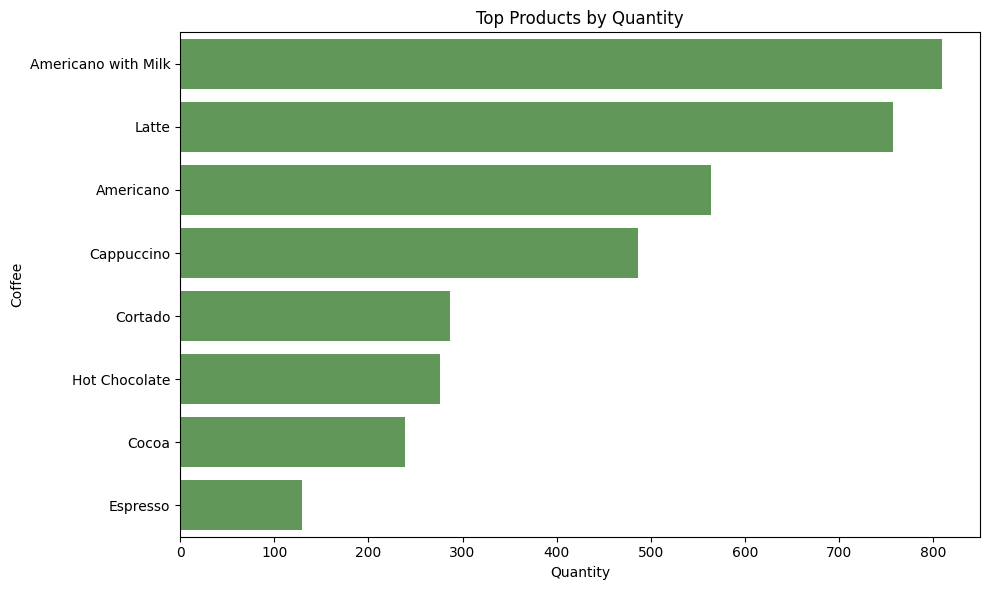

In [14]:
fig = plot_top_products(top_volume_df, value_column="quantity")
plt.tight_layout()
plt.show()

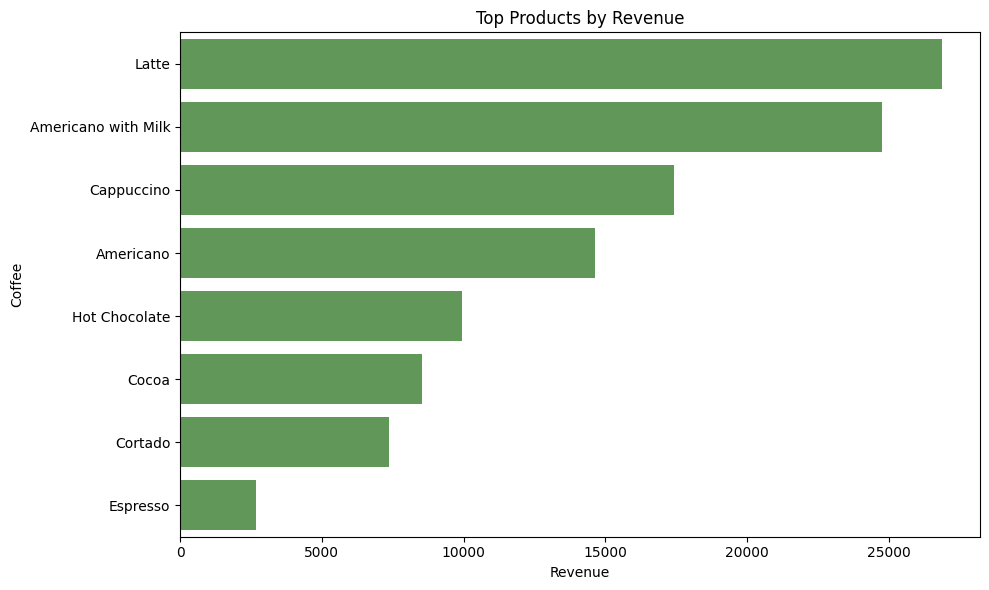

In [15]:
fig = plot_top_products(top_revenue_df, value_column="revenue")
plt.tight_layout()
plt.show()

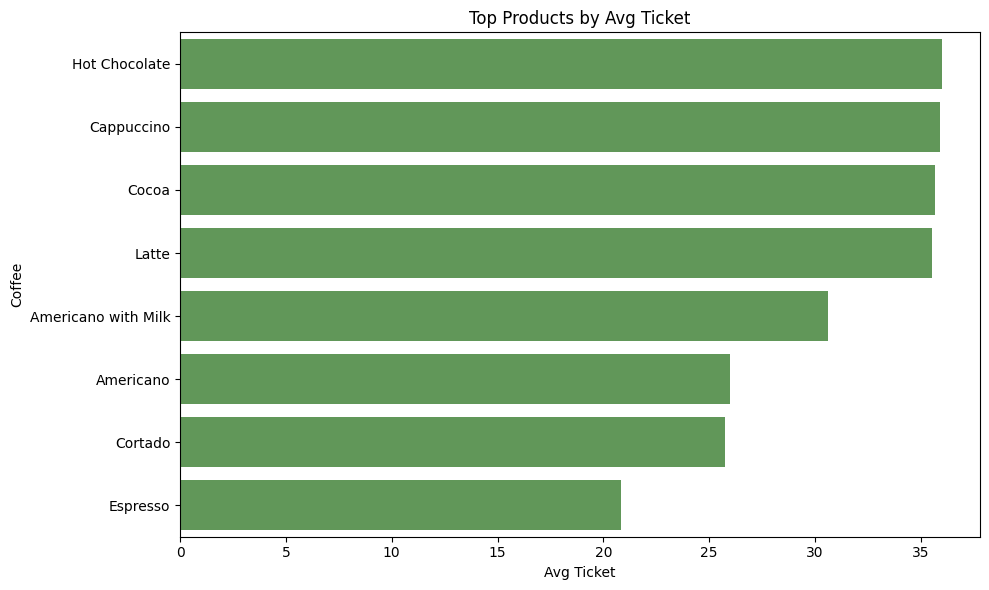

In [16]:
fig = plot_top_products(avg_ticket_df, value_column="avg_ticket")
plt.tight_layout()
plt.show()

## Behavioral Pattern Analysis
Uncover time-product and weekday-product purchase concentration using cross-tabulations and heatmaps. Answers Q6 (best product per time of day), Q11 (time-of-day preferences), Q12 (hourly distribution), and Q13 (weekday–hour peak combinations). Checkpoint 5 deliverables: hour×product, time-of-day×product, weekday×product, and weekday×hour heatmaps.

In [17]:
best_tod_df = best_product_per_time_of_day(analysis_df)
peak_per_hour_df = peak_product_per_hour(analysis_df)

print("Q6 — Best-selling product per time of day:")
display(best_tod_df)
print("Peak product per hour of day:")
display(peak_per_hour_df)

Q6 — Best-selling product per time of day:


,Time_of_Day,coffee_name,quantity,revenue
0,Afternoon,Latte,270,9611.10
1,Morning,Americano with Milk,331,10025.52
2,Night,Latte,272,9614.02


Peak product per hour of day:


,hour_of_day,coffee_name,transactions
0,6,Americano,2
1,7,Latte,30
2,8,Americano with Milk,51
3,9,Americano with Milk,94
4,10,Americano with Milk,101
5,11,Americano,71
6,12,Americano,55
7,13,Americano with Milk,56
8,14,Latte,47
9,15,Latte,64


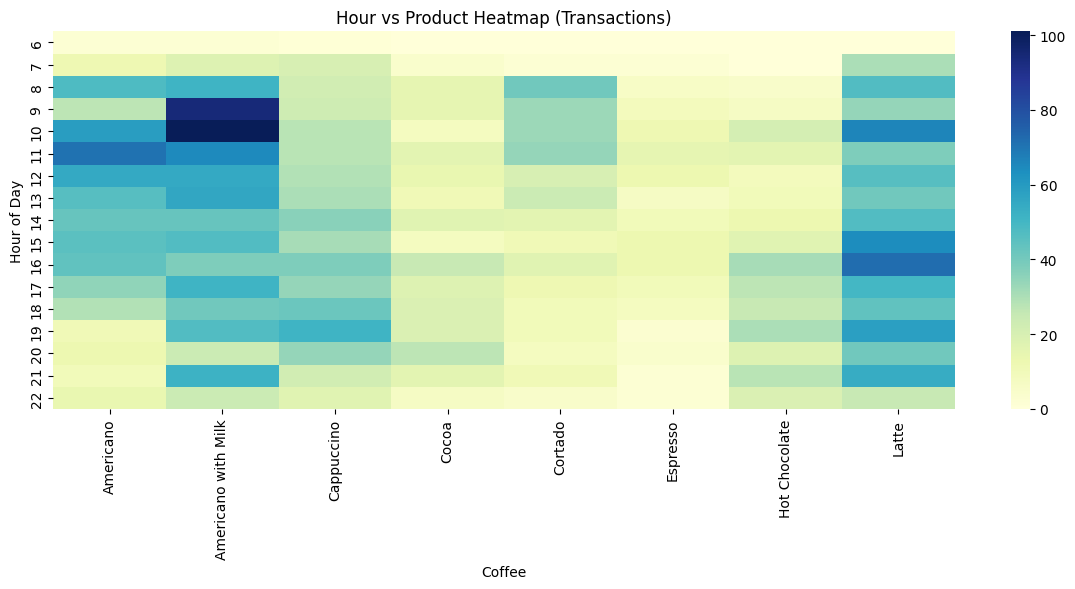

In [18]:
fig = plot_hour_product_heatmap(analysis_df)
plt.tight_layout()
plt.show()

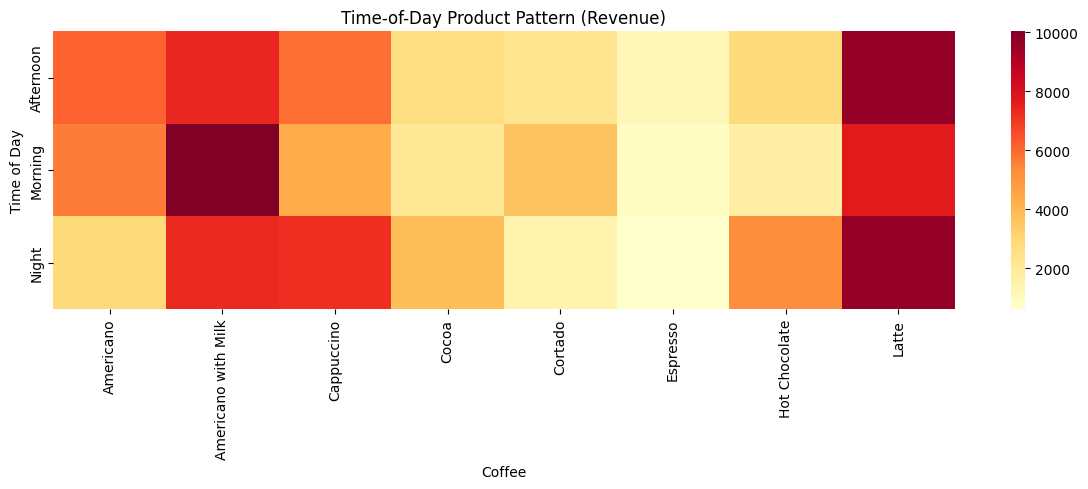

In [19]:
fig = plot_time_product_heatmap(analysis_df)
plt.tight_layout()
plt.show()

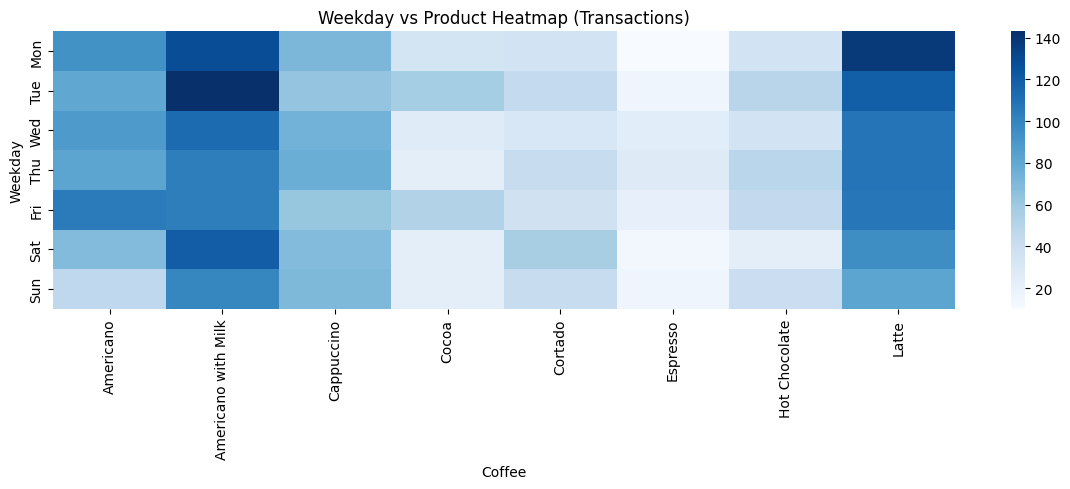

In [20]:
fig = plot_weekday_product_heatmap(analysis_df)
plt.tight_layout()
plt.show()

In [21]:
weekday_hour_df = peak_weekday_hour(analysis_df)
display(weekday_hour_df.head(15))

,Weekday,hour_of_day,transactions,revenue
0,Tue,19,52,1737.02
1,Tue,11,56,1728.16
2,Mon,10,52,1650.78
3,Sat,11,55,1602.24
4,Tue,16,50,1599.84
5,Sun,10,47,1543.52
6,Mon,16,46,1540.10
7,Fri,9,51,1493.50
8,Thu,19,43,1486.72
9,Thu,10,49,1486.66


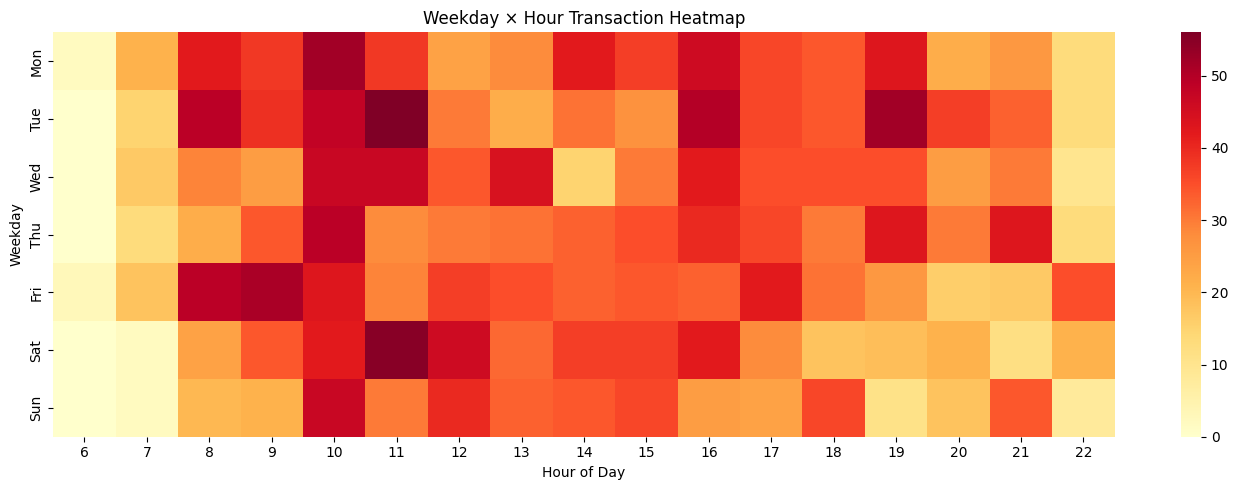

In [22]:
fig = plot_weekday_hour_heatmap(analysis_df)
plt.tight_layout()
plt.show()

## Key Business Findings
Direct answers to remaining analytical questions: Q7 (lowest-transaction weekday) and Q15 (under-performing products relative to product revenue average).

In [23]:
weekday_tx_df = transactions_by_weekday(analysis_df)
lowest_tx_weekday = weekday_tx_df.sort_values("transactions").head(1)

print("Q7 — Weekday with lowest number of transactions:")
display(lowest_tx_weekday)

print(f"\nQ9 — Overall average transaction value: {overview['average_transaction_value']:.2f}")

Q7 — Weekday with lowest number of transactions:


,Weekdaysort,Weekday,transactions
6,7,Sun,419



Q9 — Overall average transaction value: 31.65


In [24]:
under_df = underperforming_products(analysis_df)

print("Q15 — Under-performing products (revenue below product average):")
display(under_df)

Q15 — Under-performing products (revenue below product average):


,coffee_name,revenue,gap_to_avg
0,Espresso,2690.28,11340.4175
1,Cortado,7384.86,6645.8375
2,Cocoa,8521.16,5509.5375
3,Hot Chocolate,9933.46,4097.2375


## Summary

**Dataset:** 3,547 transactions · £112,245.58 total revenue · £31.65 average transaction · 8 products across 381 trading days (2024-03-01 → 2025-03-23).

### Revenue & Timing
- **Afternoon (12:00–17:59)** generates the most revenue of the three time buckets, with Morning second and Night third. Staffing and inventory should be weighted toward midday and early-afternoon hours.
- **10 am** is the single peak hour by transaction count (328 transactions, £10,198.52 revenue), making late-morning the most critical operational window.
- **Tuesday** records the highest weekday revenue (£18,168.38); **Sunday** is the weakest (£13,336.06).
- Monthly revenue peaks in **March** and dips sharply in **April**, with a secondary recovery in September–October.

### Product Performance
- **Americano with Milk** leads by transaction count (809 sales), but **Latte** generates the highest total revenue (£26,875.30) due to its higher unit price.
- **Espresso, Cortado, Cocoa, and Hot Chocolate** all fall below the product revenue average (~£14,031) and are candidates for targeted promotions or menu repositioning.
- Average ticket values are consistent across products (range: £18–£38), reflecting a fixed-price menu with little variation per item.

### Behavioral Patterns
- Latte and Americano with Milk dominate across all time-of-day buckets and weekdays, reinforcing their status as the core revenue drivers.
- The hour×product and weekday×product heatmaps confirm that product preferences shift modestly between Morning, Afternoon, and Night — Espresso sees relatively higher concentration in Morning hours.
- The weekday×hour heatmap reveals Tuesday–Thursday 9 am–11 am as the consistently highest-activity window, useful for targeted promotions or staff allocation.

### Operational Recommendations
- **Staff peak hours:** Prioritise coverage at 10 am and the surrounding late-morning window.
- **Promote low performers:** Run targeted discounts or bundle promotions for Espresso and Cortado, particularly in Afternoon and Night slots where their demand is weakest.
- **Inventory:** Weight stock toward Latte and Americano with Milk as both volume and revenue leaders.
- **Payment method:** Only card transactions are present in this dataset; cash or other payment method analysis is not applicable.